<a href="https://colab.research.google.com/github/w3aarush/deep-learning/blob/main/MNIST_using_MobileNetV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.image import resize as tf_resize

In [2]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# freeze the base model's convolutional layers so we don't destroy its knowledge
base_model.trainable = False

# build our new assembly line, snapping our custom head onto the pretrained body
model = Sequential()

# add the frozen convolutional layer
model.add(base_model)

# add custom layers to translate the findings in our categories
model.add(Flatten())
model.add(Dense(10, activation='softmax'))

# compilation
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Transfer learning model successfully assembled.")

/tmp/ipykernel_2027/2869439589.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))


Transfer learning model successfully assembled.


In [3]:
# loading the dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [4]:
X_train.shape

(60000, 28, 28)

In [5]:
# This step ensures the images have 3 channels, as expected by MobileNetV2.
# Add a channel dimension for RGB (from 28x28 to 28x28x3)
X_train_rgb = np.stack((X_train,)*3, axis=-1)
X_test_rgb = np.stack((X_test,)*3, axis=-1)

In [6]:
X_train_padded = np.pad(X_train_rgb, ((0, 0), (2, 2), (2, 2), (0, 0)), mode='constant')
X_test_padded = np.pad(X_test_rgb, ((0, 0), (2, 2), (2, 2), (0, 0)), mode='constant')

In [9]:
print(X_train_rgb.shape)
print(X_test_rgb.shape)
print(X_test_padded.shape)
print(X_train_padded.shape)

(60000, 28, 28, 3)
(10000, 28, 28, 3)
(10000, 32, 32, 3)
(60000, 32, 32, 3)


In [ ]:
# Resize images to the expected 224x224 input size for MobileNetV2
X_train_resized = tf_resize(X_train_rgb, (224, 224)).numpy()
X_test_resized = tf_resize(X_test_rgb, (224, 224)).numpy()
print(X_train_resized.shape)
print(X_test_resized.shape)

In [10]:
# Normalize pixel values to be between 0 and 1
X_train_final = X_train_padded / 255.0
X_test_final = X_test_padded / 255.0

# Convert integer labels to one-hot encoded categorical labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

print(f"Shape of X_train_final: {X_train_final.shape}")
print(f"Shape of X_test_final: {X_test_final.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train_final: (60000, 32, 32, 3)
Shape of X_test_final: (10000, 32, 32, 3)
Shape of y_train: (60000, 10)
Shape of y_test: (10000, 10)


In [11]:
model.fit(X_train_final, y_train, epochs=8, validation_data=(X_test_final, y_test))

Epoch 1/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 91s 45ms/step - accuracy: 0.4541 - loss: 1.6920 - val_accuracy: 0.5109 - val_loss: 1.4606
Epoch 2/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 98s 52ms/step - accuracy: 0.5309 - loss: 1.3958 - val_accuracy: 0.5398 - val_loss: 1.3395
Epoch 3/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 95s 50ms/step - accuracy: 0.5479 - loss: 1.3171 - val_accuracy: 0.5553 - val_loss: 1.2864
Epoch 4/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - accuracy: 0.5566 - loss: 1.2792 - val_accuracy: 0.5572 - val_loss: 1.2591
Epoch 5/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 43ms/step - accuracy: 0.5627 - loss: 1.2570 - val_accuracy: 0.5613 - val_loss: 1.2397
Epoch 6/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 43ms/step - accuracy: 0.5657 - loss: 1.2422 - val_accuracy: 0.5671 - val_loss: 1.2284
Epoch 7/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 76s 40ms/step - accuracy: 0.5678 - loss: 1.2319 - val_accuracy: 0.5659 - val_loss: 1.2196
Epoch 8/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 89s 44ms/step - accuracy: 0.5699 - loss: 1

In [12]:
model.save('my_version_MobileNetV2.keras')

In [13]:
import matplotlib.pyplot as plt

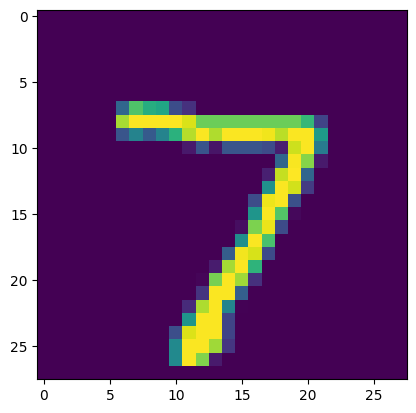

In [17]:
image = plt.imshow(X_test[0])

In [23]:
test_image = X_test_final[0:1]

prediction_prob = model.predict(test_image)
print(prediction_prob)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
[[2.2922330e-04 4.9515800e-03 9.1707943e-06 1.5088041e-04 3.3600636e-02
  1.2667270e-04 7.7987141e-05 9.5986503e-01 2.5615920e-05 9.6317113e-04]]


In [24]:
np.argmax(prediction_prob)

np.int64(7)

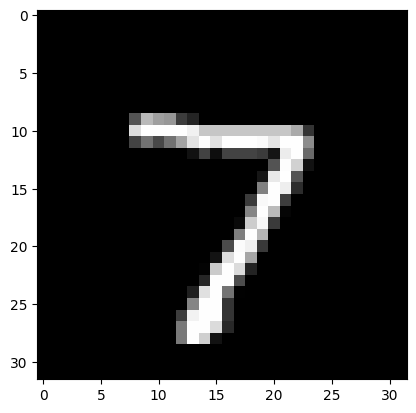

In [25]:
plt.imshow(X_test_final[0])